# MAT-55 — Reconhecimento de Dígitos Manuscritos
## Post-processing: figuras e tabelas a partir de `results/`

Este notebook **lê os arquivos `.npz`** produzidos pelos experimentos e
gera as figuras do relatório. Não treina classificadores nem carrega o MNIST
— é puro e rápido, pensado para iterar sobre os gráficos.

**Pré-requisito:** todos os experimentos já rodaram e `results/` contém os
oito arquivos `.npz`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS = Path("../results")   # adjust if you run from elsewhere
FIGS = Path("../figures"); FIGS.mkdir(exist_ok=True)

# consistent style
plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "axes.labelsize": 16,
        "axes.titlesize": 18,
        "legend.fontsize": 13,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "lines.linewidth": 2.5,
        "lines.markersize": 5,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
    }
)


# a fixed color per method, used everywhere
COLORS = {
    "svd":   "#2c6fbb",
    "knn":   "#d6453d",
    "ls":    "#3fa34d",
    "sklearn_knn":   "#e08e0b",
    "sklearn_ridge": "#7d5ba6",
}

def peek(name):
    """Load an .npz and print its keys + shapes, so you see what's inside."""
    d = np.load(RESULTS / name)
    print(f"{name}:")
    for k in d.files:
        v = d[k]
        print(f"   {k:24} shape={v.shape} dtype={v.dtype}")
    return d

## 0. Inspect every results file

Run this first to confirm all eight `.npz` are present and see their keys.

In [2]:
for f in sorted(RESULTS.glob("*.npz")):
    peek(f.name); print()

confusion_matrices.npz:
   svd_subspace             shape=(10, 10) dtype=int64
   knn                      shape=(10, 10) dtype=int64
   ls                       shape=(10, 10) dtype=int64
   sklearn_knn              shape=(10, 10) dtype=int64
   sklearn_ridge            shape=(10, 10) dtype=int64

eckart_young.npz:
   r_values                 shape=(9,) dtype=int64
   residuals                shape=(10, 9) dtype=float64

final_comparison.npz:
   method_names             shape=(5,) dtype=<U20
   test_accuracies          shape=(5,) dtype=float64
   fit_times                shape=(5,) dtype=float64
   predict_times            shape=(5,) dtype=float64
   best_r                   shape=() dtype=int64
   best_k                   shape=() dtype=int64
   best_alpha               shape=() dtype=float64
   svd_scratch_full_fit_time shape=() dtype=float64
   svd_scratch_test_acc     shape=() dtype=float64
   svd_projector_diff       shape=() dtype=float64

knn_sweep.npz:
   k_values             

## 1. SVD-subspace: accuracy vs r (the bias–variance curve)

The headline curve for the subspace method: underfit at low `r`, peak around
`r=20`–`30`, slight overfit by `r=50` as extra singular vectors model noise.

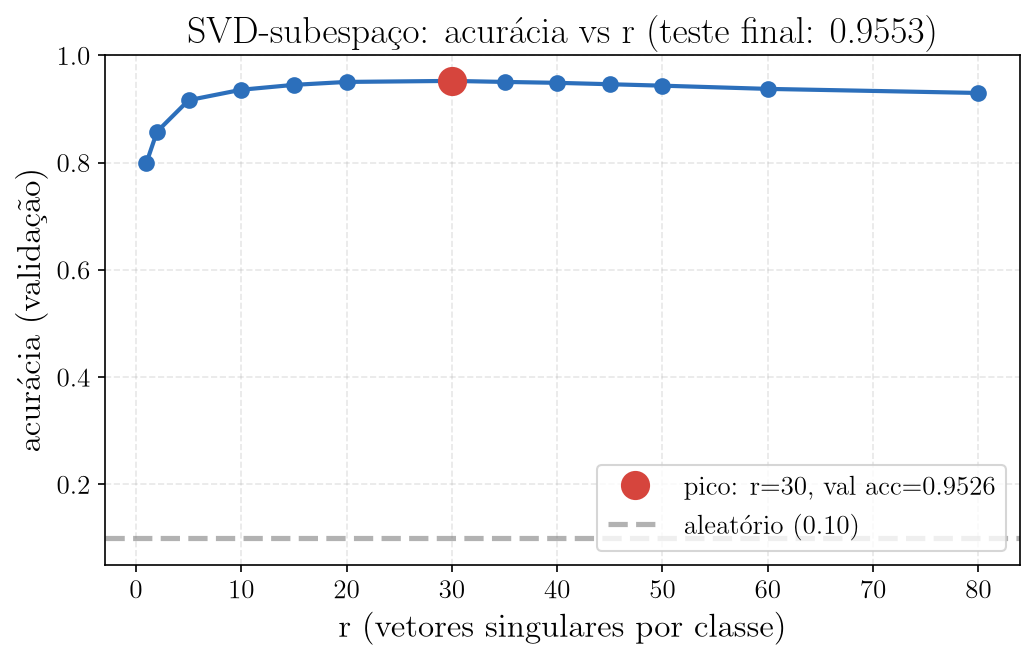

In [3]:
d = np.load(RESULTS / "svd_subspace_sweep.npz")
r = d["r_values"]; acc = d["val_accuracies"]
best_r = int(d["best_r"]); final = float(d["final_test_acc"])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(r, acc, "o-", color=COLORS["svd"], lw=2, ms=7)
bi = int(np.argmax(acc))
ax.plot(r[bi], acc[bi], "o", color="#d6453d", ms=13, zorder=5,
        label=f"pico: r={best_r}, val acc={acc[bi]:.4f}")
ax.axhline(0.10, ls="--", color="gray", alpha=0.6, label="aleatório (0.10)")
ax.set_xlabel("r  (vetores singulares por classe)")
ax.set_ylabel("acurácia (validação)")
ax.set_title(f"SVD-subespaço: acurácia vs r   (teste final: {final:.4f})")
ax.legend(loc="lower right"); ax.set_ylim(0.05, 1.0)
plt.tight_layout(); plt.savefig(FIGS / "svd_accuracy_vs_r.png", dpi=130); plt.show()

## 2. kNN: accuracy vs k

On MNIST, `k=1` wins — digits cluster so tightly that averaging over more
neighbors only pulls in other classes.

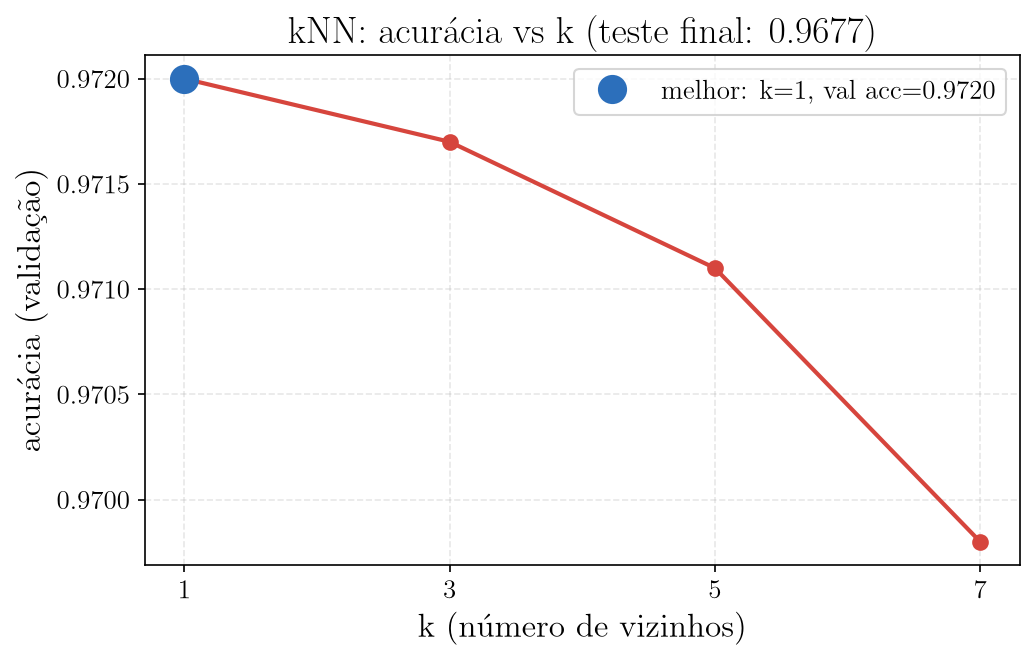

In [4]:
d = np.load(RESULTS / "knn_sweep.npz")
k = d["k_values"]; acc = d["val_accuracies"]
best_k = int(d["best_k"]); final = float(d["final_test_acc"])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(k, acc, "o-", color=COLORS["knn"], lw=2, ms=7)
bi = int(np.argmax(acc))
ax.plot(k[bi], acc[bi], "o", color="#2c6fbb", ms=13, zorder=5,
        label=f"melhor: k={best_k}, val acc={acc[bi]:.4f}")
ax.set_xlabel("k  (número de vizinhos)")
ax.set_ylabel("acurácia (validação)")
ax.set_title(f"kNN: acurácia vs k   (teste final: {final:.4f})")
ax.set_xticks(k); ax.legend(); plt.tight_layout()
plt.savefig(FIGS / "knn_accuracy_vs_k.png", dpi=130); plt.show()

## 3. Ridge: accuracy vs regularization (alpha)

The library reference for the LS method. Shows how regularization strength
affects accuracy; ties to the rank-deficiency story (a little regularization
helps because MNIST's effective rank is ~700 < 784).

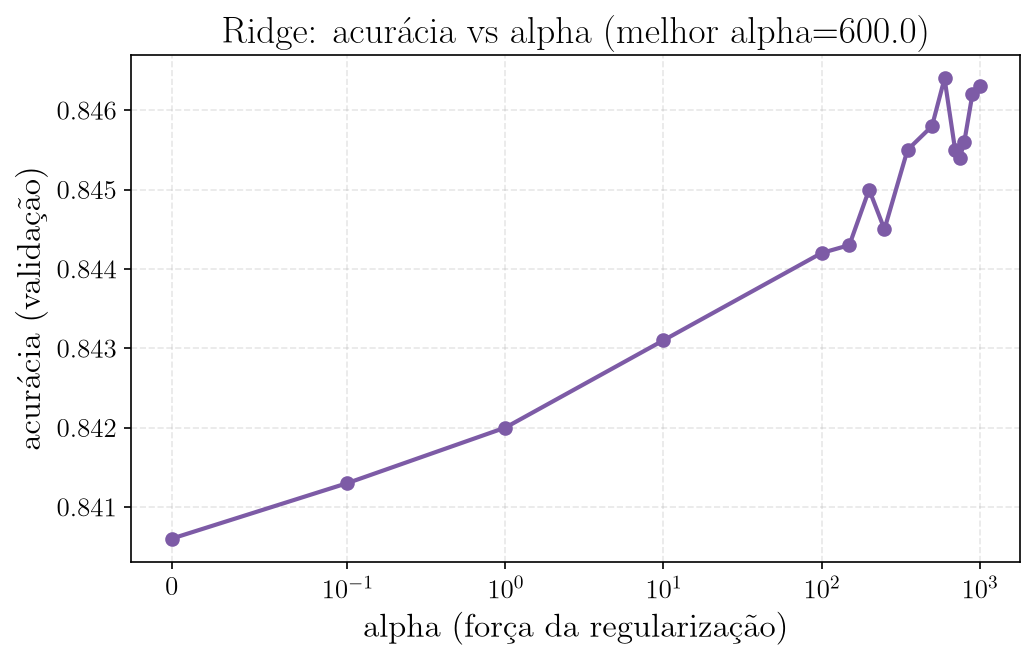

In [5]:
d = np.load(RESULTS / "sklearn_ridge_sweep.npz")
alpha = d["alpha_values"]; acc = d["val_accuracies"]
best_alpha = float(d["best_alpha"])

fig, ax = plt.subplots(figsize=(7, 4.5))
# alpha spans orders of magnitude; symlog handles the 0.0 entry
ax.plot(alpha, acc, "o-", color=COLORS["sklearn_ridge"], lw=2, ms=6)
ax.set_xscale("symlog", linthresh=0.1)
ax.set_xlabel("alpha  (força da regularização)")
ax.set_ylabel("acurácia (validação)")
ax.set_title(f"Ridge: acurácia vs alpha   (melhor alpha={best_alpha})")
plt.tight_layout(); plt.savefig(FIGS / "ridge_accuracy_vs_alpha.png", dpi=130); plt.show()

## 4. Confusion matrices (one heatmap per classifier)

The qualitative analysis promised in the preview. Bright off-diagonal cells
are systematic confusions (classically 4↔9, 3↔5, 7↔9). LS confuses far more
than the subspace/kNN methods — visible as a brighter off-diagonal.

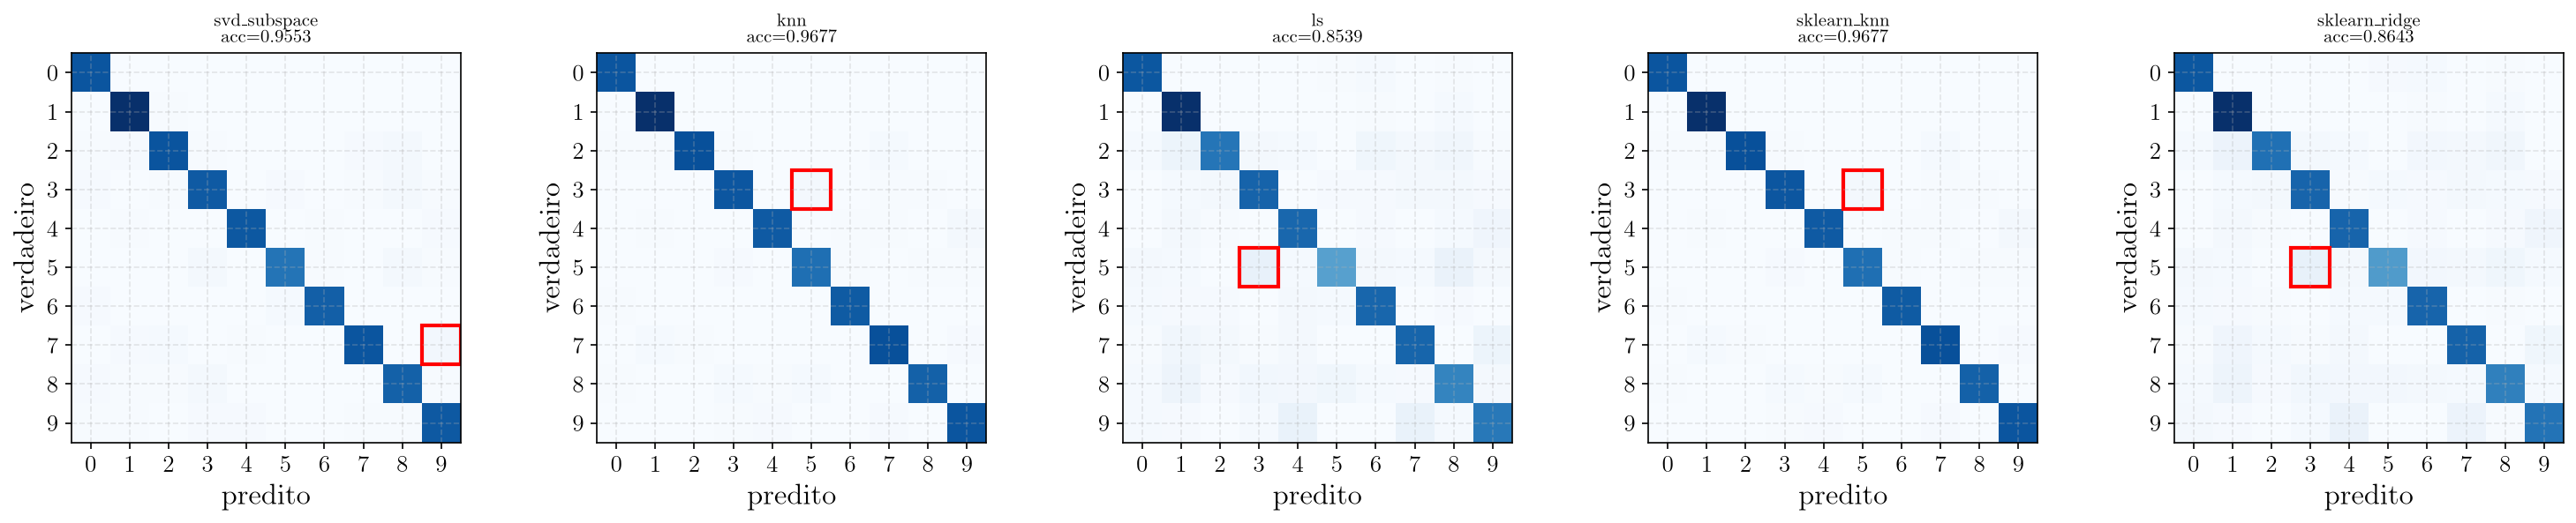

In [6]:
d = np.load(RESULTS / "confusion_matrices.npz")
names = d.files
fig, axes = plt.subplots(1, len(names), figsize=(4*len(names), 3.8))
if len(names) == 1: axes = [axes]
for ax, name in zip(axes, names):
    C = d[name]
    acc = np.trace(C) / C.sum()
    im = ax.imshow(C, cmap="Blues")
    ax.set_title(f"{name}\nacc={acc:.4f}", fontsize=10)
    ax.set_xlabel("predito"); ax.set_ylabel("verdadeiro")
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    # annotate the largest off-diagonal cell
    Coff = C.copy(); np.fill_diagonal(Coff, 0)
    i, j = np.unravel_index(np.argmax(Coff), Coff.shape)
    ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False,
                               edgecolor="red", lw=2))
plt.tight_layout(); plt.savefig(FIGS / "confusion_matrices.png", dpi=130); plt.show()

### 4b. Confusion matrices, log-scaled (to see the off-diagonal structure)

Linear color washes out the small confusion counts against the huge diagonal.
A log scale on the *off-diagonal only* makes the confusion pattern legible.
One figure per classifier: `figures/confusion_<name>_log.png`.

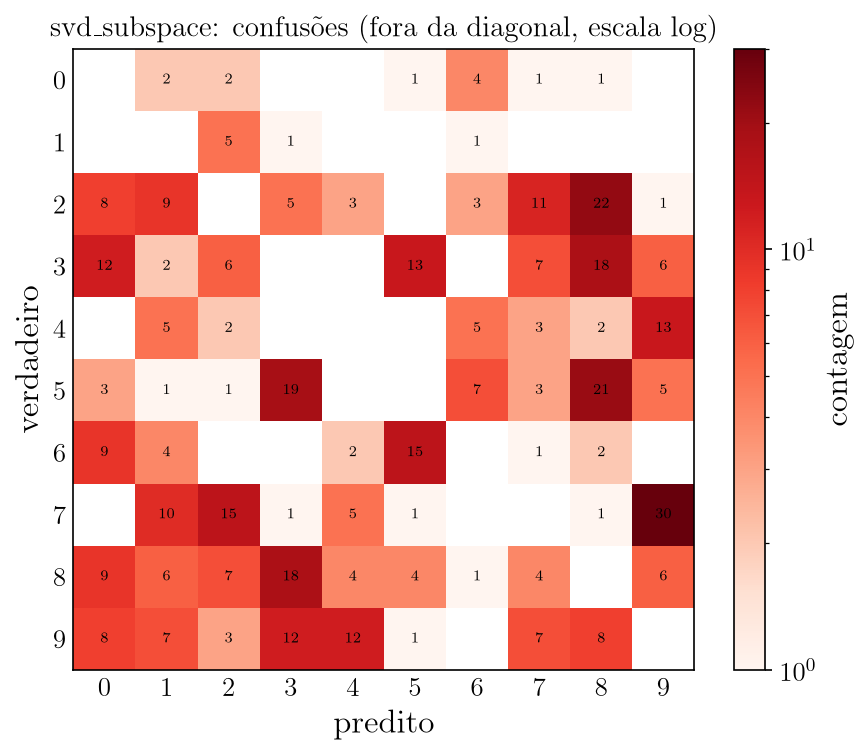

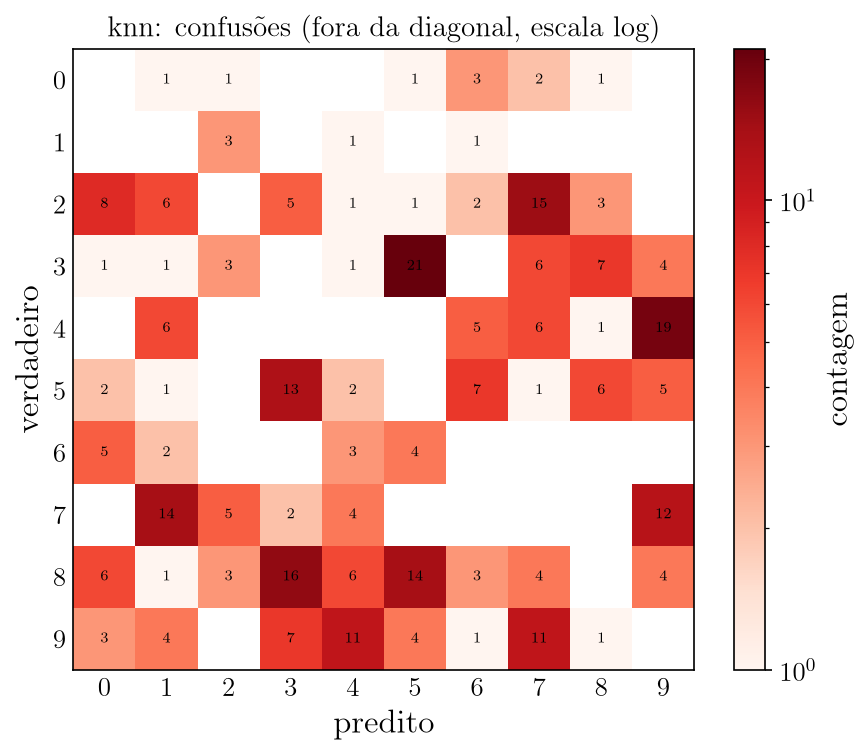

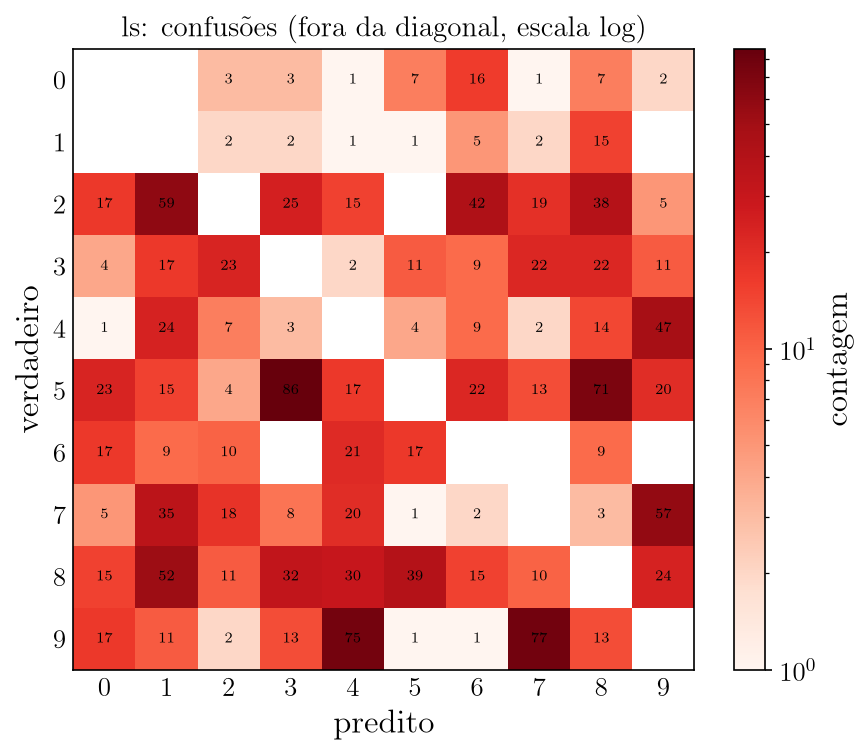

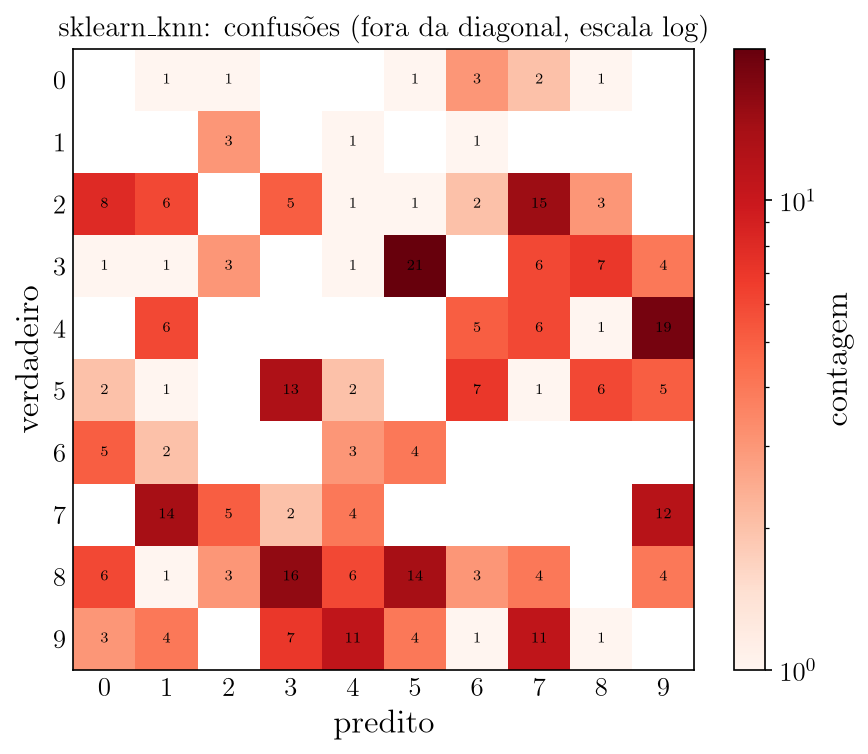

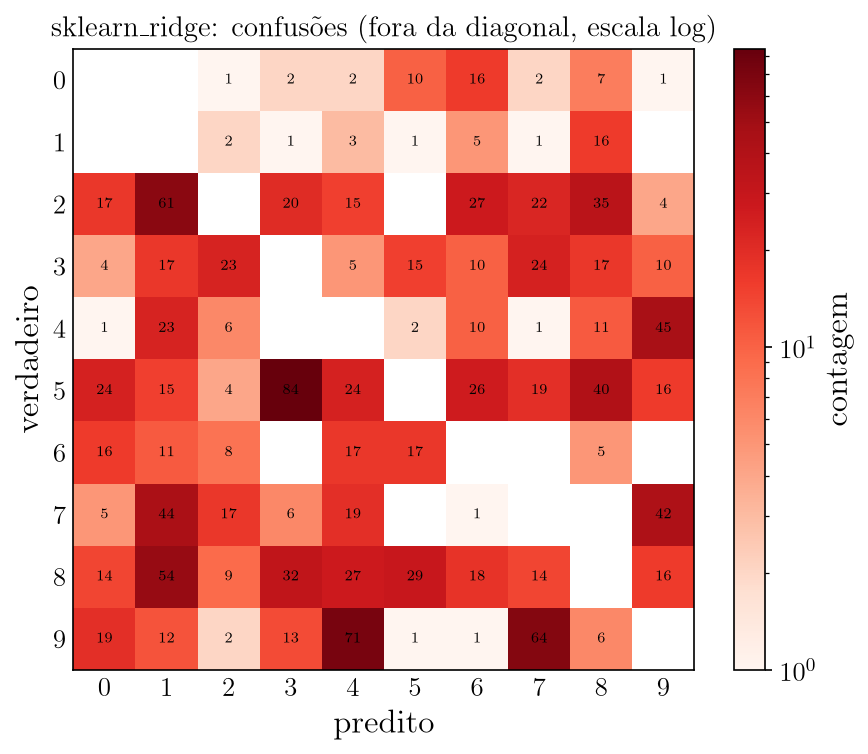

In [7]:
import matplotlib.colors as mcolors

d = np.load(RESULTS / "confusion_matrices.npz")
for name in d.files:
    C = d[name].astype(float)
    Coff = C.copy(); np.fill_diagonal(Coff, 0)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(Coff, cmap="Reds",
                   norm=mcolors.LogNorm(vmin=1, vmax=Coff.max()))
    ax.grid(False)
    ax.tick_params(which="both", length=0)
    ax.set_title(f"{name}: confusões (fora da diagonal, escala log)", fontsize=14)
    ax.set_xlabel("predito"); ax.set_ylabel("verdadeiro")
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    for i in range(10):
        for j in range(10):
            if Coff[i, j] > 0:
                ax.text(j, i, int(Coff[i, j]), ha="center", va="center",
                        fontsize=7, color="black")
    plt.colorbar(im, ax=ax, label="contagem")
    plt.tight_layout(); plt.savefig(FIGS / f"confusion_{name}_log.png", dpi=130); plt.show()

## 5. Eckart–Young residual curves

For each digit class, the relative Frobenius residual of the rank-r truncation,
||A_k − A_{k,r}||_F / ||A_k||_F. This empirically justifies *why* the subspace
method works: the residual drops fast, so each digit class is well-approximated
by a low-rank subspace. Digit 1 (simplest strokes) is most compressible.

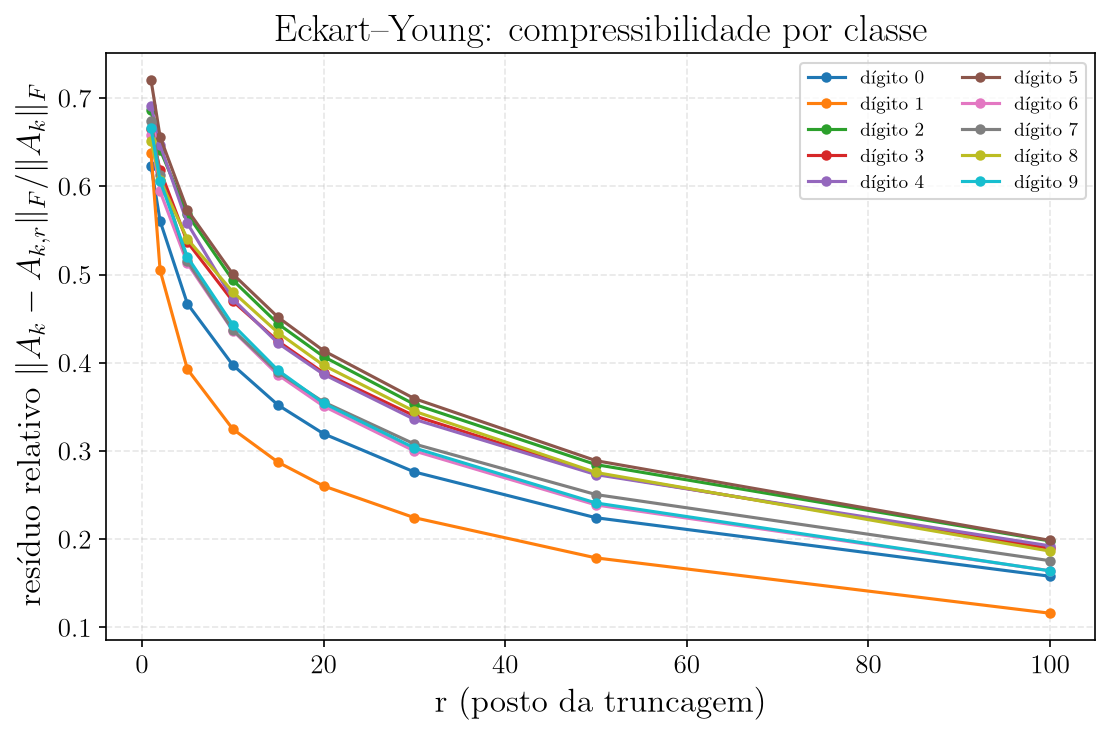

In [8]:
d = np.load(RESULTS / "eckart_young.npz")
r = d["r_values"]; res = d["residuals"]   # (10, len(r))

fig, ax = plt.subplots(figsize=(7.5, 5))
cmap = plt.cm.tab10
for k in range(10):
    ax.plot(r, res[k], "o-", color=cmap(k), lw=1.5, ms=4, label=f"dígito {k}")
ax.set_xlabel("r  (posto da truncagem)")
ax.set_ylabel(r"resíduo relativo  $\|A_k - A_{k,r}\|_F / \|A_k\|_F$")
ax.set_title("Eckart–Young: compressibilidade por classe")
ax.legend(ncol=2, fontsize=9)
plt.tight_layout(); plt.savefig(FIGS / "eckart_young_residuals.png", dpi=130); plt.show()

## 6. The headline comparison: accuracy vs prediction cost

The single figure that tells the whole story. Each method is a point: accuracy
(y) vs prediction time (x, log scale). The ideal corner is top-left — high
accuracy, fast prediction. kNN is accurate but slow; SVD-subspace is nearly as
accurate and predicts ~250× faster than scratch kNN (~75× faster than
scikit-learn's kNN); LS is fast but weak.

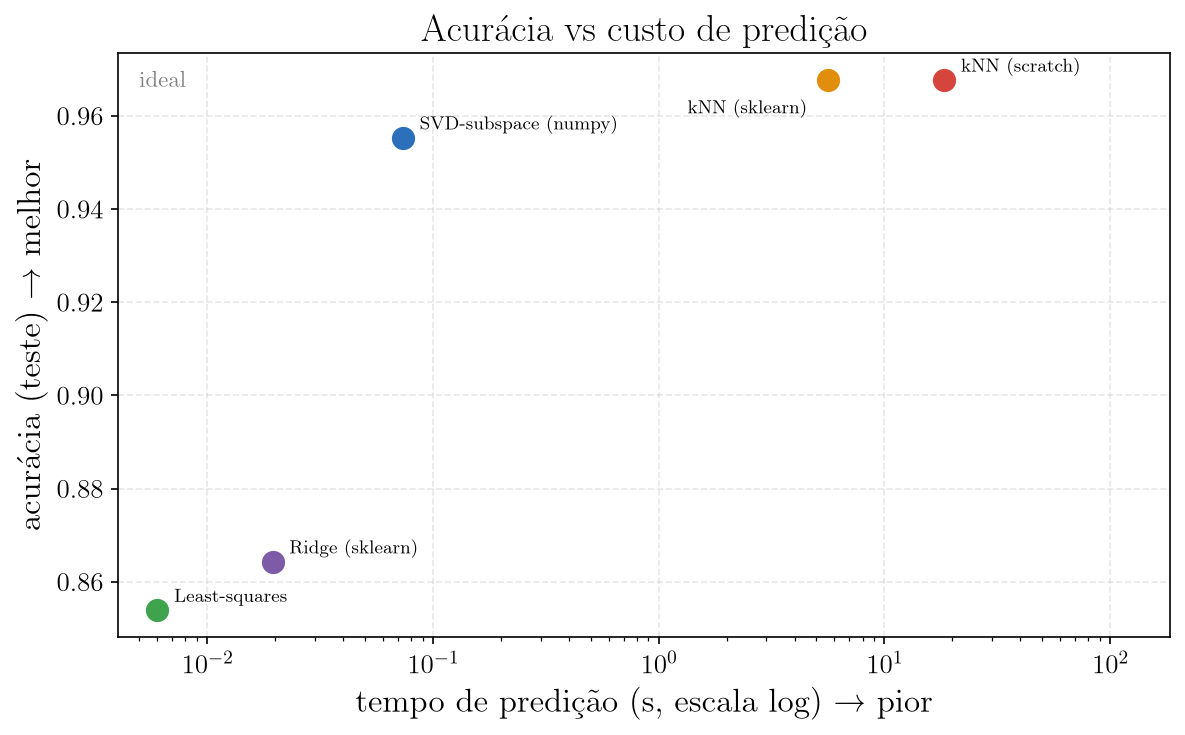

In [9]:
d = np.load(RESULTS / "final_comparison.npz")
names = [str(n) for n in d["method_names"]]
acc = d["test_accuracies"]; fit = d["fit_times"]; pred = d["predict_times"]

# map display names to colors
def cof(n):
    n=n.lower()
    if "svd" in n: return COLORS["svd"]
    if "ridge" in n: return COLORS["sklearn_ridge"]
    if "least" in n: return COLORS["ls"]
    if "sklearn" in n and "knn" in n: return COLORS["sklearn_knn"]
    if "knn" in n: return COLORS["knn"]
    return "#444"

# the two kNN points sit at almost the same accuracy: put sklearn's label below-left
LABEL_OFFSETS = {"kNN (sklearn)": ((-10, -16), "right")}

fig, ax = plt.subplots(figsize=(8, 5))
for n, a, p in zip(names, acc, pred):
    ax.scatter(max(p, 1e-3), a, s=160, color=cof(n), zorder=3, edgecolor="white", lw=1.5)
    (dx, dy), ha = LABEL_OFFSETS.get(n, ((8, 4), "left"))
    ax.annotate(n, (max(p, 1e-3), a), xytext=(dx, dy), ha=ha,
                textcoords="offset points", fontsize=9)
ax.set_xscale("log")
ax.set_xlim(right=pred.max() * 10)   # room for the right-most label
ax.set_xlabel("tempo de predição (s, escala log)  →  pior")
ax.set_ylabel("acurácia (teste)  →  melhor")
ax.set_title("Acurácia vs custo de predição")
ax.annotate("ideal", xy=(0.02, 0.97), xycoords="axes fraction", ha="left", va="top",
            fontsize=11, color="gray", style="italic")
plt.tight_layout(); plt.savefig(FIGS / "accuracy_vs_cost.png", dpi=130); plt.show()

## 7. Final comparison table

The numeric summary for the report. Also pulls in the SVD scratch full-data
timing and the projector-equivalence proof.

In [10]:
d = np.load(RESULTS / "final_comparison.npz")
names = [str(n) for n in d["method_names"]]
acc = d["test_accuracies"]; fit = d["fit_times"]; pred = d["predict_times"]

print(f"{'método':<22} | {'acurácia':>9} | {'fit (s)':>8} | {'predição (s)':>12}")
print("-"*60)
for n, a, f, p in zip(names, acc, fit, pred):
    print(f"{n:<22} | {a:>9.4f} | {f:>8.2f} | {p:>12.2f}")

print()
print(f"SVD scratch (dados completos): fit={float(d['svd_scratch_full_fit_time']):.1f}s, "
      f"acc={float(d['svd_scratch_test_acc']):.4f}")
print(f"Diferença de projetor (scratch vs numpy): {float(d['svd_projector_diff']):.2e}")
print(f"Hiperparâmetros: r={int(d['best_r'])}, k={int(d['best_k'])}, alpha={float(d['best_alpha'])}")

método                 |  acurácia |  fit (s) | predição (s)
------------------------------------------------------------
SVD-subspace (numpy)   |    0.9553 |    13.22 |         0.07
kNN (scratch)          |    0.9677 |     0.00 |        18.42
Least-squares          |    0.8539 |     4.30 |         0.01
kNN (sklearn)          |    0.9677 |     0.04 |         5.63
Ridge (sklearn)        |    0.8643 |     0.57 |         0.02

SVD scratch (dados completos): fit=183.5s, acc=0.9553
Diferença de projetor (scratch vs numpy): 2.58e-15
Hiperparâmetros: r=30, k=1, alpha=600.0


## 8. (optional) LaTeX table for direct paste into the report

Generates a `tabular` you can drop straight into the `.tex`.

In [11]:
d = np.load(RESULTS / "final_comparison.npz")
names = [str(n) for n in d["method_names"]]
acc = d["test_accuracies"]; fit = d["fit_times"]; pred = d["predict_times"]

print(r"\begin{tabular}{lrrr}")
print(r"\toprule")
print(r"Método & Acurácia & Treino (s) & Predição (s) \\")
print(r"\midrule")
for n, a, f, p in zip(names, acc, fit, pred):
    print(f"{n} & {a:.4f} & {f:.2f} & {p:.2f} " + r"\\")
print(r"\bottomrule")
print(r"\end{tabular}")

\begin{tabular}{lrrr}
\toprule
Método & Acurácia & Treino (s) & Predição (s) \\
\midrule
SVD-subspace (numpy) & 0.9553 & 13.22 & 0.07 \\
kNN (scratch) & 0.9677 & 0.00 & 18.42 \\
Least-squares & 0.8539 & 4.30 & 0.01 \\
kNN (sklearn) & 0.9677 & 0.04 & 5.63 \\
Ridge (sklearn) & 0.8643 & 0.57 & 0.02 \\
\bottomrule
\end{tabular}
